## 0. Importar las librerías que vamos a utilizar y los datasets

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [2]:
# Importar datasets
# Ruta base
ruta = "../Data/2_cleaned/"

# Importación de datasets limpios
deuda = pd.read_csv(ruta + "deuda.csv")
paro = pd.read_csv(ruta + "paro.csv")
pib = pd.read_csv(ruta + "pib.csv")
poblacion = pd.read_csv(ruta + "poblacion.csv")
ppcapita = pd.read_csv(ruta + "ppcapita.csv")
ventas = pd.read_csv(ruta + "ventas.csv")




## 1. Hacer merge para unificar el dataframe en uno solo

In [3]:
# 1er merge para agrupar los valores macroeconomicos en una sola tabla

macro = (
    deuda
    .merge(paro, on=['Country', 'Year'], how='outer')
    .merge(pib, on=['Country', 'Year'], how='outer')
    .merge(poblacion, on=['Country', 'Year'], how='outer')
    .merge(ppcapita, on=['Country', 'Year'], how='outer')
)

# Merge final con ventas
ventas_macro = ventas.merge(macro, on=['Country', 'Year'], how='left')
ventas_macro.head()

# - Como hay paises que no muestran datos macroeconomicos, recibimos nulos y pandas no puede interpretarlos con int, por ello transforma a float
# para arregarlo, podemos cambiar al tipo de datos 'Int64' que permite NaN

columnas_int = [
    'Deuda total (M.€)',
    'Deuda Per Cápita',
    'PIB anual (M€)',
    'Población',
    'PIB Per Capita (€)'
]

for col in columnas_int:
    ventas_macro[col] = ventas_macro[col].astype('Int64')


In [4]:
ventas_macro.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,Hour,Week,YearMonth,isCancelled,Deuda total (M.€),Deuda (%PIB),Deuda Per Cápita,Tasa de desempleo,PIB anual (M€),Población,PIB Per Capita (€)
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009,12,1,7,49,2009-12,False,1101852,63.2,17627,7.7,1738067,62510197,27920
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,7,49,2009-12,False,1101852,63.2,17627,7.7,1738067,62510197,27920
2,489434,79323W,white cherry lights,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,7,49,2009-12,False,1101852,63.2,17627,7.7,1738067,62510197,27920
3,489434,22041,"record frame 7"" single size",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009,12,1,7,49,2009-12,False,1101852,63.2,17627,7.7,1738067,62510197,27920
4,489434,21232,strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009,12,1,7,49,2009-12,False,1101852,63.2,17627,7.7,1738067,62510197,27920


## 2. Analisis

### 2.1 Analisis temporal de las ventas

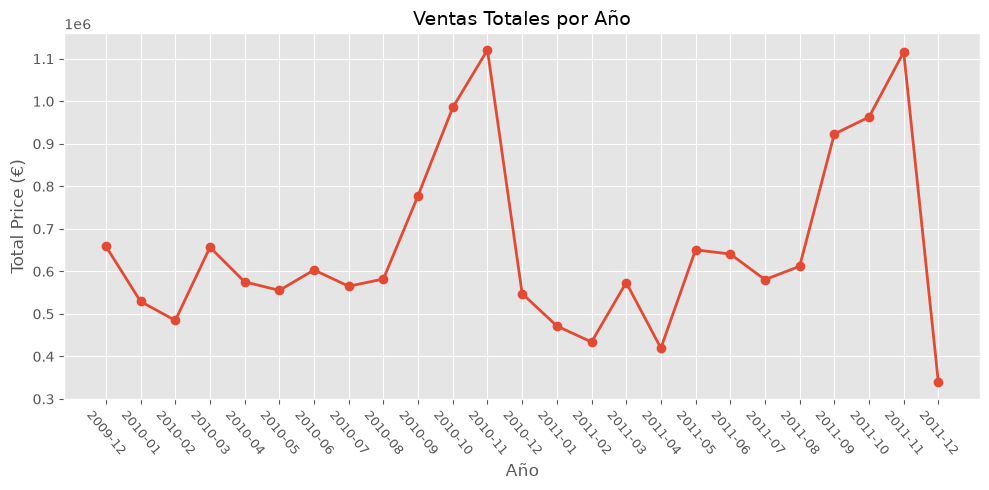

In [5]:
plt.style.use('ggplot')

# Creamos la columna
ventas['total_price'] = ventas['Price'] * ventas['Quantity']

# Agrupamos
ventas_fecha = ventas.groupby('YearMonth')['total_price'].sum().round(2).reset_index()

# Gráfico temporal
plt.figure(figsize=(10,5))

plt.plot(
    ventas_fecha['YearMonth'],
    ventas_fecha['total_price'],
    marker='o',
    markersize=6,        # tamaño del punto
    linewidth=2          # grosor de la línea
)

plt.title('Ventas Totales por Año', fontsize=14)     # título más pequeño
plt.xlabel('Año', fontsize=12)                       # etiqueta eje X más pequeña
plt.ylabel('Total Price (€)', fontsize=12)           # etiqueta eje Y más pequeña

plt.xticks(rotation=310, fontsize=9)                 # ticks más pequeños
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


# CONCLUSIONES:
# - Las ventas muestran un patrón claramente estacional.
# - Los meses con mayor volumen de ventas son septiembre, octubre y especialmente noviembre.
# - Tras noviembre, las ventas caen en diciembre y se mantienen bajas durante los primeros meses del año.
# - Este comportamiento sugiere que el negocio tiene un pico fuerte en otoño,
#   probablemente relacionado con compras previas a Navidad.


### 2.2 Análisis sobre la cantidad vendidad y dinero generado

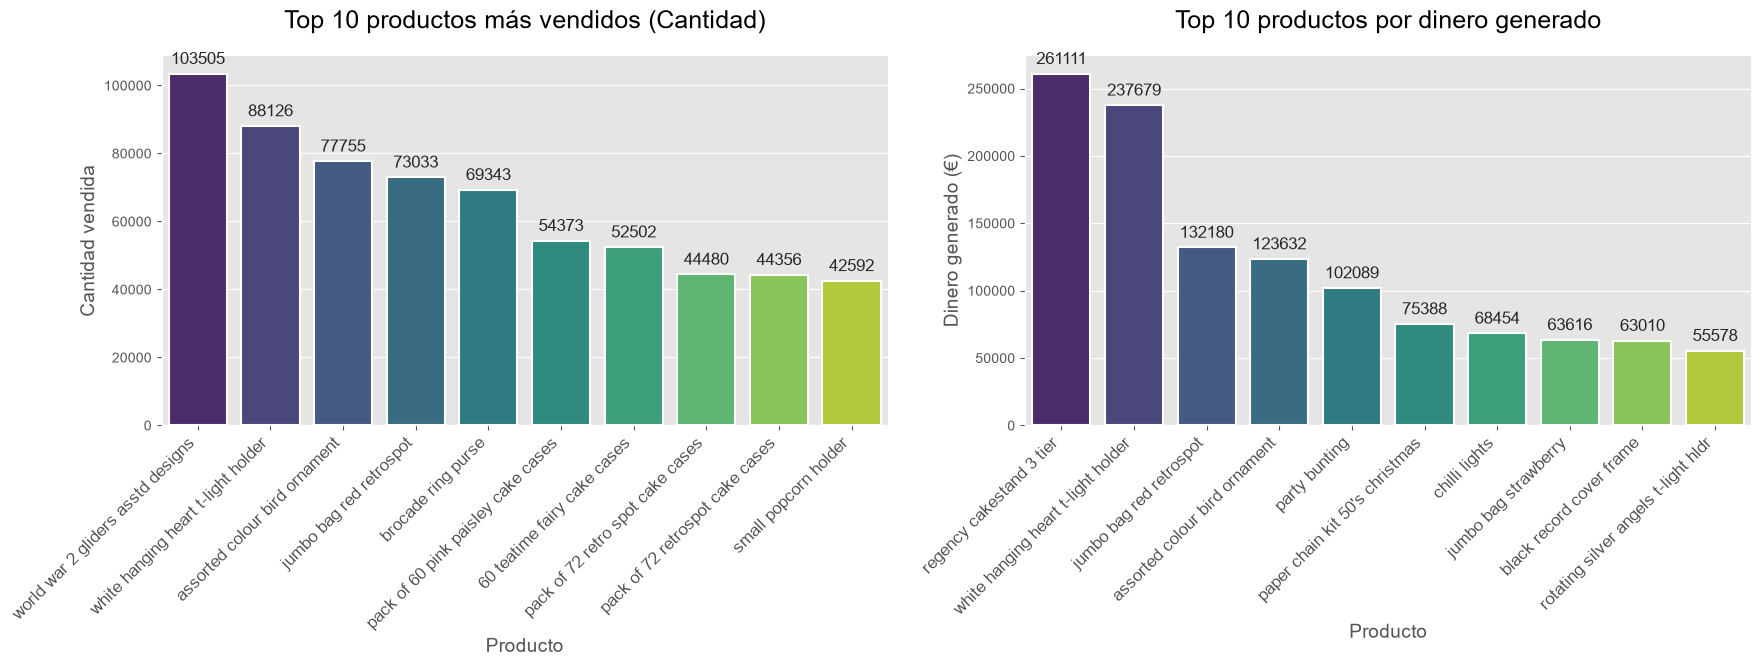

In [6]:
# Agrupar cantidad vendidas por producto
cant_producto = ventas_macro.groupby('Description')['Quantity'].sum().reset_index()
cant_producto = cant_producto.sort_values(ascending=False, by = 'Quantity').head(10)
cant_producto

# Agupar cantidad de dinero genreado por producto
ventas_macro['LineTotal'] = ventas_macro['Price'] * ventas_macro['Quantity']
ventas_producto = ventas_macro.groupby('Description')['LineTotal'].sum().reset_index()
ventas_producto = ventas_producto.sort_values(ascending=False, by = 'LineTotal').head(10)
ventas_producto

import matplotlib.gridspec as gridspec

# Crear figura con 2 ejes del mismo tamaño usando GridSpec
fig = plt.figure(figsize=(18,7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1,1])  # Ambos gráficos ocupan el mismo espacio

axs0 = fig.add_subplot(gs[0])
axs1 = fig.add_subplot(gs[1])

sns.set_style("whitegrid") # Cambia el fondo y cuadricula
sns.set_context("talk") # Ajusta el tamaño de los elementos del grafico

# ---------------------------------------------------------
# GRÁFICO 1 (IZQUIERDA): Cantidad vendida por producto
# ---------------------------------------------------------

sns.barplot(
    data=cant_producto,
    x='Description',
    y='Quantity',
    hue='Description',
    legend=False,
    ax=axs0,
    palette='viridis' # Paleta de colores
)

# Fijar ticks y etiquetas correctamente
axs0.set_xticks(range(len(cant_producto))) # Fijar los ticks del eje X en función del número de barras que vamos a mostrar
axs0.set_xticklabels(cant_producto['Description'], rotation=45, ha='right', fontsize=12) # alineamos a la derecha (ha='right') y aumentamos el tamaño de fuente.

axs0.set_ylabel("Cantidad vendida", fontsize=14)
axs0.set_xlabel("Producto", fontsize=14)
axs0.set_title("Top 10 productos más vendidos (Cantidad)", fontsize=18, pad=20) # Título del gráfico, con tamaño grande y separación superior (pad=20)

sns.despine()

# Añadir valores encima de cada barra
for p in axs0.patches:
    axs0.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=12
    )

# ---------------------------------------------------------
# GRÁFICO 2 (DERECHA): Dinero generado por producto
# ---------------------------------------------------------

sns.barplot(
    data=ventas_producto,
    x='Description',
    y='LineTotal',
    hue='Description',
    legend=False,
    ax=axs1,
    palette='viridis'
)

axs1.set_xticks(range(len(ventas_producto)))
axs1.set_xticklabels(ventas_producto['Description'], rotation=45, ha='right', fontsize=12)

axs1.set_ylabel("Dinero generado (€)", fontsize=14)
axs1.set_xlabel("Producto", fontsize=14)
axs1.set_title("Top 10 productos por dinero generado", fontsize=18, pad=20)

sns.despine()

for p in axs1.patches:
    axs1.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=12
    )

plt.tight_layout()
plt.show()

# VALIDACIÓN DE CONCLUSIONES (correctas y bien definidas)

# 1. Productos equilibrados:
#    - white hanging heart t-light holder
#    - paper craft, little birdie
#    Ambos aparecen en el top de cantidad y en el top de ingresos,
#    por lo que son productos con buena rotación y buen rendimiento económico.

# 2. Producto muy vendido pero barato:
#    - world war 2 gliders asstd designs
#    Es el nº1 en cantidad vendida, pero no aparece en el ranking de ingresos.
#    Esto confirma que es un producto de bajo precio y bajo impacto económico.

# 3. Producto poco vendido pero caro:
#    - regency cakestand 3 tier
#    No está en el top de cantidad, pero es el nº1 en dinero generado.
#    Es un producto premium: pocas ventas, pero alto valor por unidad.


### 2.3 Análisis de ventas canceladas vs compleadas

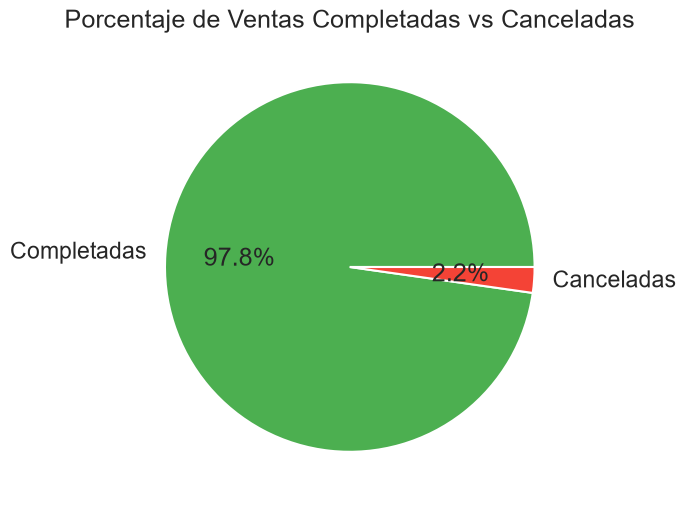

776941 17813


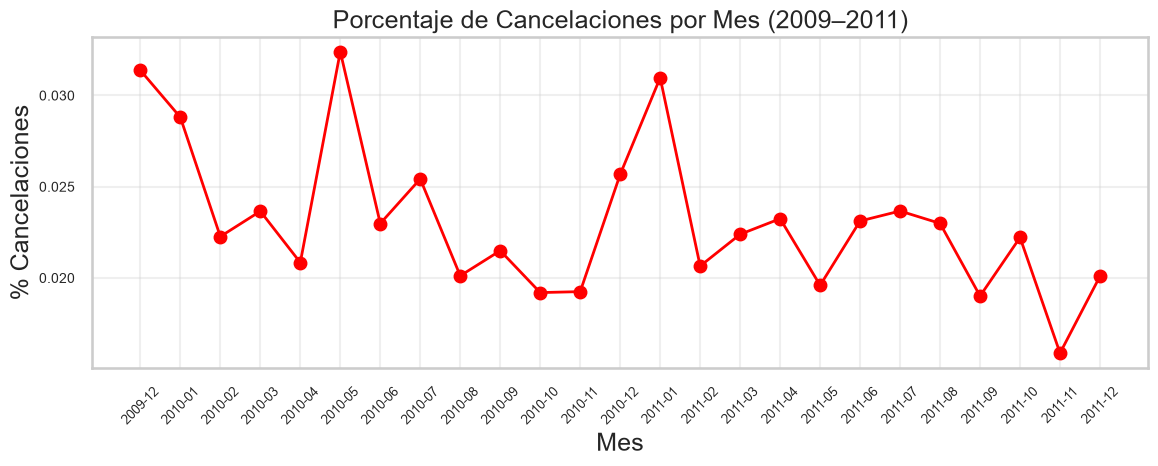

In [7]:
canceladas = ventas_macro['isCancelled'][ventas_macro['isCancelled'] == True]
canceladas = canceladas.size

completadas = completadas = ventas_macro['isCancelled'][ventas_macro['isCancelled'] == False]
completadas = completadas.size

# Gráfico circular
plt.figure(figsize=(6,6))
plt.pie([completadas, canceladas],
        labels=['Completadas', 'Canceladas'],
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'])
plt.title('Porcentaje de Ventas Completadas vs Canceladas')
plt.show()

print(completadas, canceladas)

# Podemos observar que tenemos un indice muy bajo de cancelación de productos

cancelaciones_mes = ventas_macro.groupby('YearMonth')['isCancelled'].mean()
cancelaciones_mes

plt.figure(figsize=(12,5))
plt.plot(cancelaciones_mes.index, cancelaciones_mes.values,
         marker='o', color='red', linewidth=2)

plt.title('Porcentaje de Cancelaciones por Mes (2009–2011)')
plt.xlabel('Mes')
plt.ylabel('% Cancelaciones')

plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# CONCLUSIONES:
# - El % total de cancelaciones es muy bajo (≈2.2%), lo cual indica buena calidad operativa.
# - El % mensual de cancelaciones es estable entre 1.5% y 3%.
# - Los meses con menos ventas (enero, diciembre, mayo) presentan más cancelaciones,
#   probablemente por devoluciones post-navidad o incidencias puntuales.
# - Los meses con más ventas (septiembre, octubre, noviembre) tienen menos cancelaciones,
#   lo que sugiere que el sistema funciona mejor en periodos de alta actividad.


### 2.4 Análisis de ventas y cantidad de productos vendidos por paises

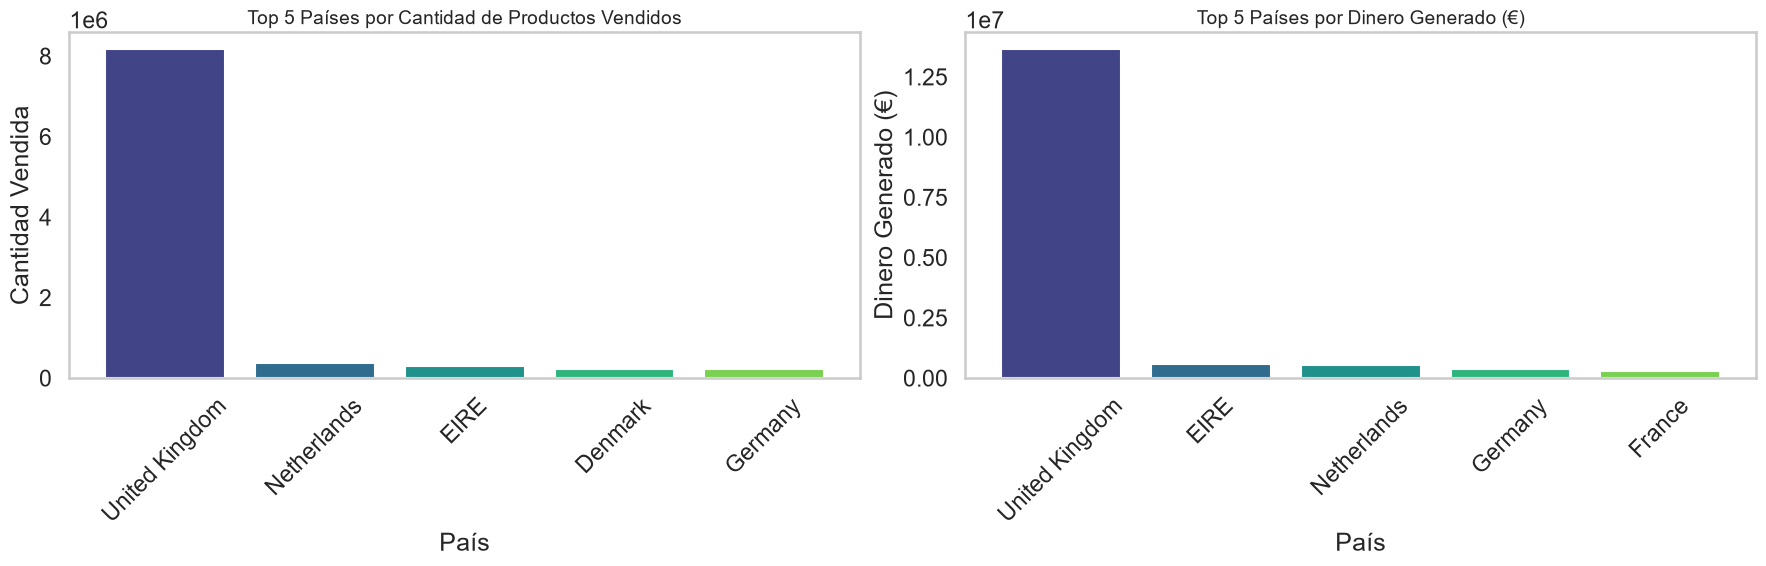

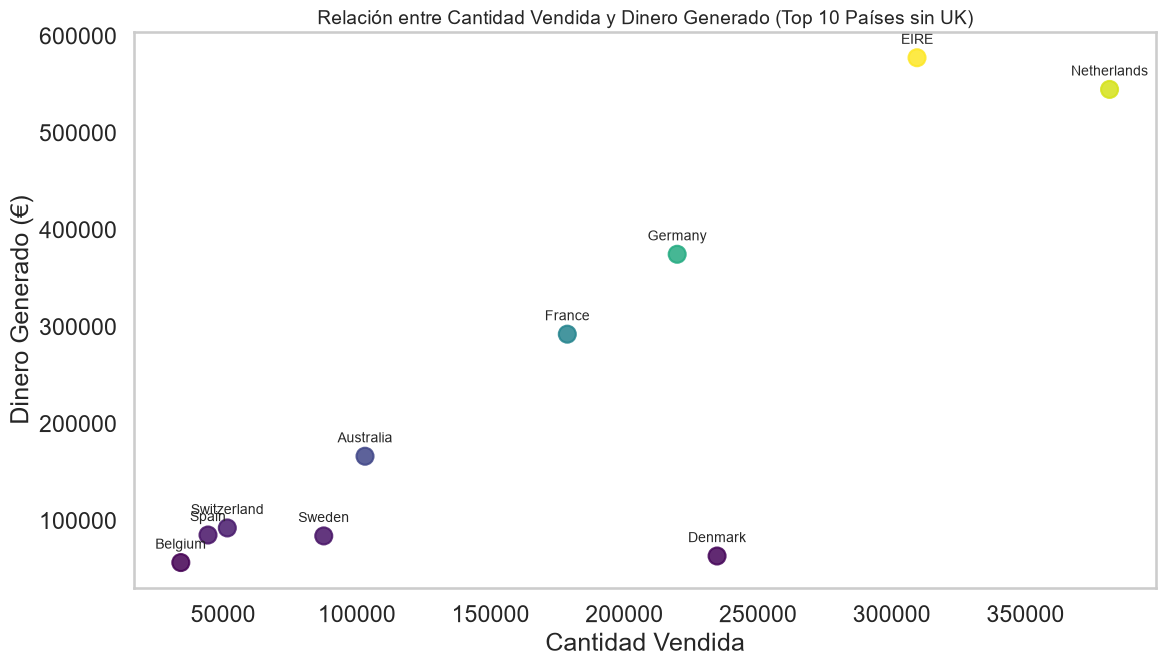

In [8]:
# Cantidad de productos vendidos por paises
cant_paises = ventas_macro.groupby('Country')['Quantity'].sum().reset_index()
cant_paises = cant_paises.sort_values(ascending = False, by = 'Quantity').head(5)
cant_paises

# Ventas totales por pais
ventas_pais = ventas_macro.groupby('Country')['LineTotal'].sum().reset_index()
ventas_pais = ventas_pais.sort_values(ascending = False, by = 'LineTotal').head(5)
ventas_pais['LineTotal'] = ventas_pais['LineTotal'].astype(int)

## Gráfico de barras

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Gráfico 1: Cantidad de productos vendidos por país ---
axes[0].bar(cant_paises['Country'], 
            cant_paises['Quantity'], 
            color=plt.cm.viridis(np.linspace(0.2, 0.8, len(cant_paises))))

axes[0].set_title('Top 5 Países por Cantidad de Productos Vendidos', fontsize=14)
axes[0].set_xlabel('País')
axes[0].set_ylabel('Cantidad Vendida')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(False)   # quitar líneas del grid

# --- Gráfico 2: Dinero generado por país ---
axes[1].bar(ventas_pais['Country'], 
            ventas_pais['LineTotal'], 
            color=plt.cm.viridis(np.linspace(0.2, 0.8, len(ventas_pais))))

axes[1].set_title('Top 5 Países por Dinero Generado (€)', fontsize=14)
axes[1].set_xlabel('País')
axes[1].set_ylabel('Dinero Generado (€)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(False)   # quitar líneas del grid

plt.tight_layout()
plt.show()

# El Reino Unido es el mercado dominante en volumen y valor, con una diferencia enorme
# respecto al resto de países. Esto indica una fuerte dependencia geográfica.
# Francia destaca como mercado premium: genera mucho dinero con menos unidades.
# Netherlands, EIRE y Germany son mercados secundarios pero estables.
# La combinación de ambos gráficos revela mercados de volumen, premium y equilibrados.


# ================================
# Scatterplot: Top 10 Países (sin UK)
# ================================

# Agrupar datos
cant_paises_all = ventas_macro.groupby('Country')['Quantity'].sum().reset_index()
ventas_pais_all = ventas_macro.groupby('Country')['LineTotal'].sum().reset_index()

# Unir ambos datasets
scatter_data = cant_paises_all.merge(ventas_pais_all, on='Country')

# Quitar UK
scatter_data = scatter_data[scatter_data['Country'] != 'United Kingdom']

# Seleccionar los 10 países con más facturación
top10 = scatter_data.sort_values(by='LineTotal', ascending=False).head(10)

plt.figure(figsize=(12, 7))

plt.scatter(
    top10['Quantity'],
    top10['LineTotal'],
    c=top10['LineTotal'],
    cmap='viridis',
    s=150,
    alpha=0.85
)

# Etiquetas con padding fijo en píxeles
for i, row in top10.iterrows():
    plt.annotate(
        row['Country'],
        (row['Quantity'], row['LineTotal']),
        textcoords="offset points",
        xytext=(0, 10),   # 10 píxeles hacia arriba
        ha='center',
        fontsize=10
    )

plt.title('Relación entre Cantidad Vendida y Dinero Generado (Top 10 Países sin UK)', fontsize=14)
plt.xlabel('Cantidad Vendida')
plt.ylabel('Dinero Generado (€)')
plt.grid(False)

plt.tight_layout()
plt.show()


## CONCLUSIONES sin UK:
# - EIRE y Netherlands destacan como los mercados más fuertes: alto volumen y alto valor.
# - France actúa como mercado premium: genera mucho dinero con menos cantidad vendida.
# - Germany y Denmark son mercados equilibrados, con valores intermedios en volumen y facturación.
# - Australia, Sweden, Switzerland, Belgium y Spain muestran bajo volumen y bajo valor,
#   indicando mercados marginales con poca relevancia estratégica.
# En conjunto, sin UK, los países que realmente sostienen el negocio son EIRE, Netherlands, France y Germany.







### 2.4 Análisis de ventas y cantidad de productos vendidos por paises

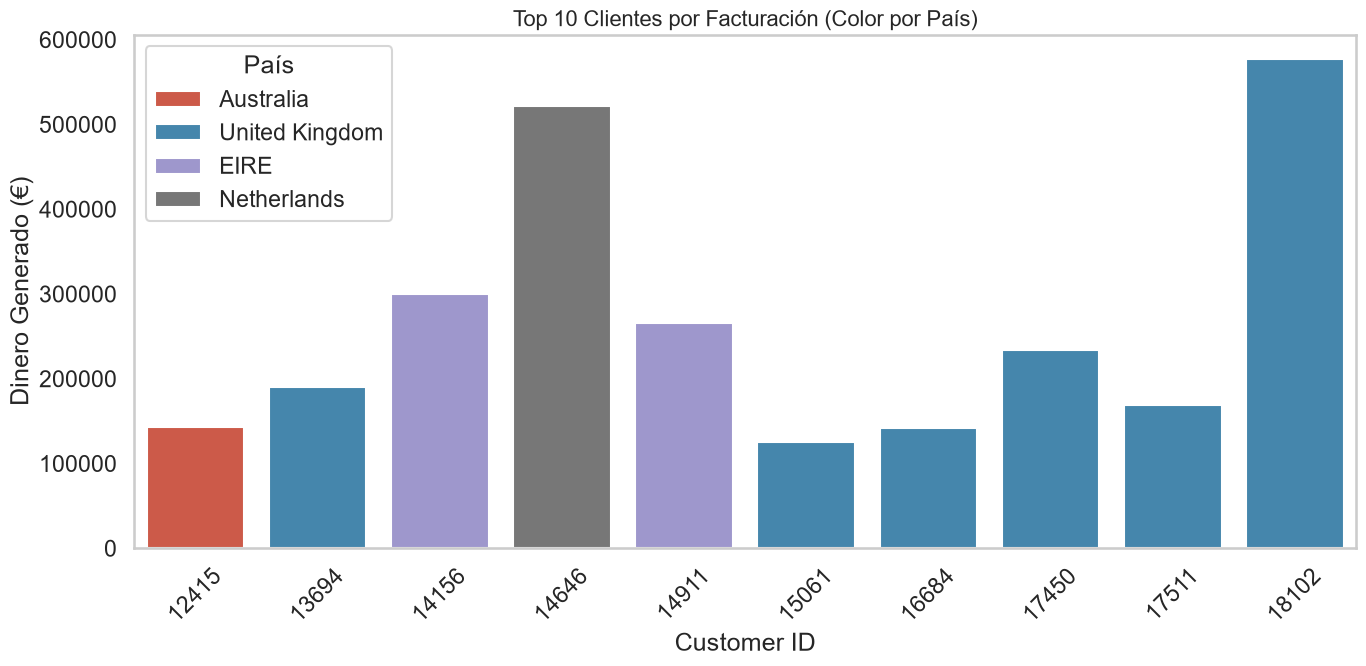

In [9]:
ventas_cli = ventas_macro.groupby('Customer ID')['LineTotal'].sum().reset_index()
ventas_cli = ventas_cli.sort_values(ascending = False, by = 'LineTotal').head(10)

# Añadir el país de cada cliente
clientes_con_pais = ventas_cli.merge(
    ventas_macro[['Customer ID', 'Country']].drop_duplicates(),
    on='Customer ID',
    how='left'
)

# Grafico de barras, 10 mejores clientes
plt.figure(figsize=(14, 7))

# Gráfico de barras con color por país
sns.barplot(
    data=clientes_con_pais,
    x='Customer ID',
    y='LineTotal',
    hue='Country'

)

plt.title('Top 10 Clientes por Facturación (Color por País)', fontsize=16)
plt.xlabel('Customer ID')
plt.ylabel('Dinero Generado (€)')
plt.xticks(rotation=45)
plt.grid(False)
plt.legend(title='País')

plt.tight_layout()
plt.show()


## Conclusiones antes del grafico: 6 de los 10 mejores clientes son de 'United Kingdom', nos confirma que tenemos dependencia geografica fuerte
# - Netherlands aporta un cliente muy potente (521k).
# - EIRE aporta dos clientes fuertes (300k y 265k).
# - Este análisis permite identificar clientes estratégicos y diseñar acciones de fidelización:
#   regalos, descuentos VIP, atención preferente o programas exclusivos.

### 2.5 Analisis macroeconomicos para entender las ventas

📊 6. Ventas per cápita

#### 2.5.1 Relación entre PIB y ventas

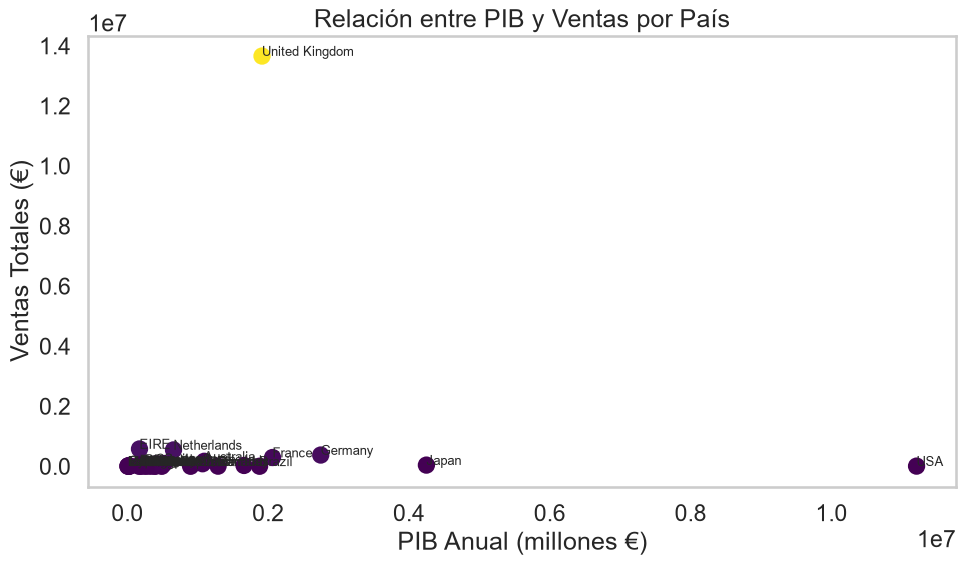

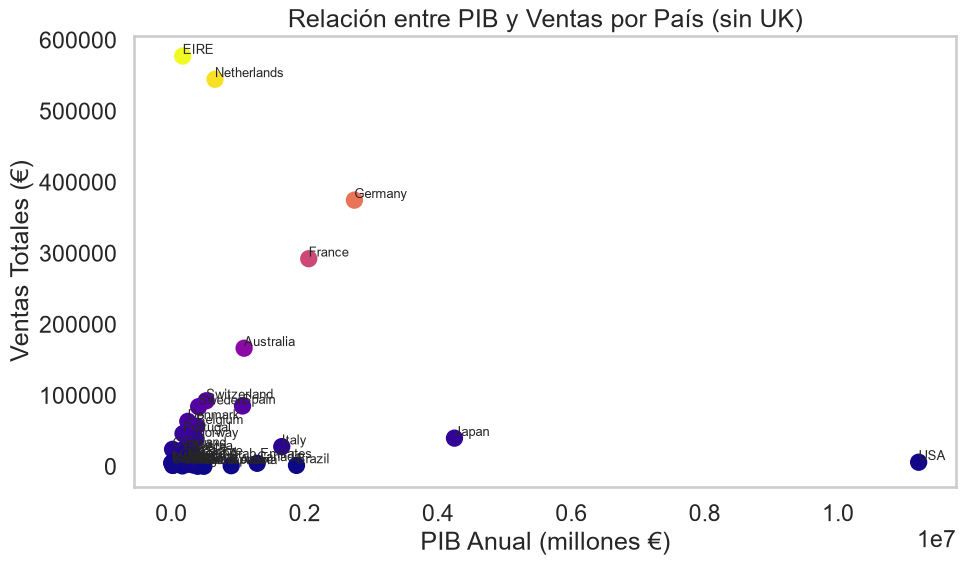

In [10]:
# ============================================================
# TABLA MACROECONÓMICA LIMPIA (último año con datos válidos)
# ============================================================

# Eliminamos filas sin PIB (evita que países desaparezcan por NaN en el último año)
macro_df = (
    ventas_macro.dropna(subset=['PIB anual (M€)'])
    .sort_values('Year')
    .groupby('Country')
    .tail(1)
)

macro_df = macro_df[['Country', 'Deuda total (M.€)', 'Deuda (%PIB)', 'Deuda Per Cápita',
                     'Tasa de desempleo', 'PIB anual (M€)', 'Población', 'PIB Per Capita (€)']]


# VENTAS TOTALES POR PAÍS (TODOS LOS PAÍSES)
ventas_pais_full = ventas_macro.groupby('Country')['LineTotal'].sum().reset_index()


# UNIR VENTAS COMPLETAS + MACROECONOMÍA COMPLETA
df_macro = ventas_pais_full.merge(macro_df, on='Country')


# ============================================================
# CORRELACIÓN PIB vs VENTAS (TODOS LOS PAÍSES)
# ============================================================

corr_pib_ventas = df_macro[['LineTotal', 'PIB anual (M€)']].corr().iloc[0,1]
corr_pib_ventas  # ~0.298 → relación débil pero existente


# ============================================================
# CORRELACIÓN SIN REINO UNIDO
# ============================================================

df_macro_sin_uk = df_macro[df_macro['Country'] != 'United Kingdom']

corr_pib_ventas_sin_uk = df_macro_sin_uk[['LineTotal', 'PIB anual (M€)']].corr().iloc[0,1]
corr_pib_ventas_sin_uk  # ~ -0.875 → relación fuertemente negativa



# Conclusiones:
# Los datos macroeconómicos estaban repetidos por cada factura, ya que cada fila incluía
# el valor macro del país para ese año. Para un análisis macroeconómico correcto, es necesario
# obtener una única fila por país usando el último año disponible con datos válidos.
#
# Además, ventas_pais contenía solo el TOP 5 de países, lo que hacía que el análisis macroeconómico
# y los scatterplots solo mostraran 5 países (y 4 al quitar UK). Para evitar esto, se crea
# ventas_pais_full, que incluye TODOS los países.
#
# Una vez agregados correctamente, la correlación PIB ↔ ventas muestra:
# - Con Reino Unido: correlación débil (~0.298), el PIB no explica bien las ventas.
# - Sin Reino Unido: correlación fuertemente negativa (~ -0.875), los países con mayor PIB
#   compran menos y los países con menor PIB compran más.
#
# Esto revela que el negocio no depende del tamaño económico del país, sino de factores
# específicos como cultura de consumo, presencia de clientes estratégicos o nichos concretos.
# El Reino Unido actuaba como outlier y ocultaba esta relación inversa.


# ============================================================
# SCATTERPLOT PIB vs VENTAS (TODOS LOS PAÍSES)
# ============================================================

plt.figure(figsize=(10,6))

plt.scatter(df_macro['PIB anual (M€)'], df_macro['LineTotal'],
            c=df_macro['LineTotal'], cmap='viridis', s=120)

for i, row in df_macro.iterrows():
    plt.text(row['PIB anual (M€)'], row['LineTotal'] + 5000, row['Country'], fontsize=9)

plt.xlabel('PIB Anual (millones €)')
plt.ylabel('Ventas Totales (€)')
plt.title('Relación entre PIB y Ventas por País')
plt.grid(False)
plt.tight_layout()
plt.show()


# ============================================================
# SCATTERPLOT SIN UK (TODOS LOS PAÍSES)
# ============================================================

plt.figure(figsize=(10,6))
plt.scatter(df_macro_sin_uk['PIB anual (M€)'], df_macro_sin_uk['LineTotal'],
            c=df_macro_sin_uk['LineTotal'], cmap='plasma', s=120)

for i, row in df_macro_sin_uk.iterrows():
    plt.text(row['PIB anual (M€)'], row['LineTotal'] + 3000, row['Country'], fontsize=9)

plt.xlabel('PIB Anual (millones €)')
plt.ylabel('Ventas Totales (€)')
plt.title('Relación entre PIB y Ventas por País (sin UK)')
plt.grid(False)
plt.tight_layout()
plt.show()


#### 2.5.2 PIB per capita por ticket medio

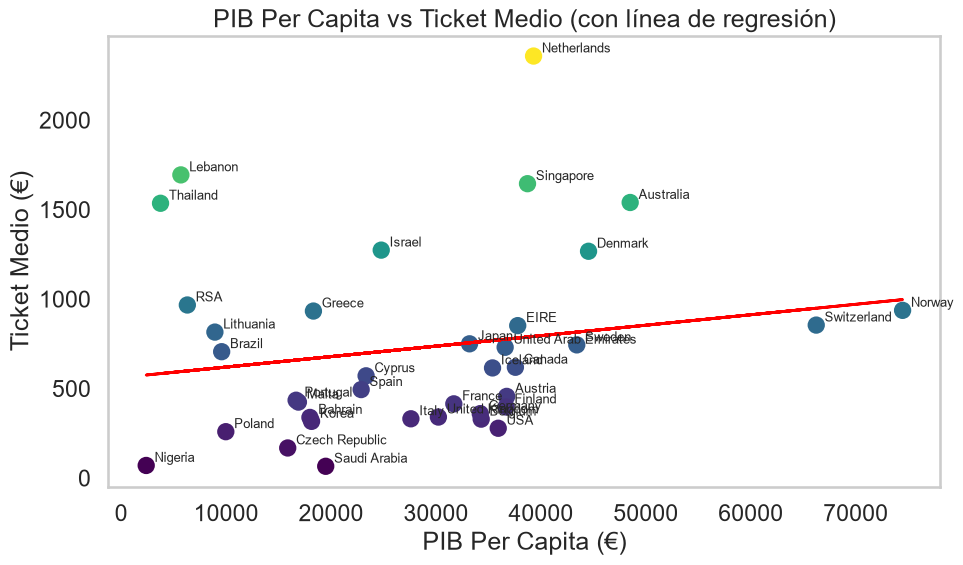

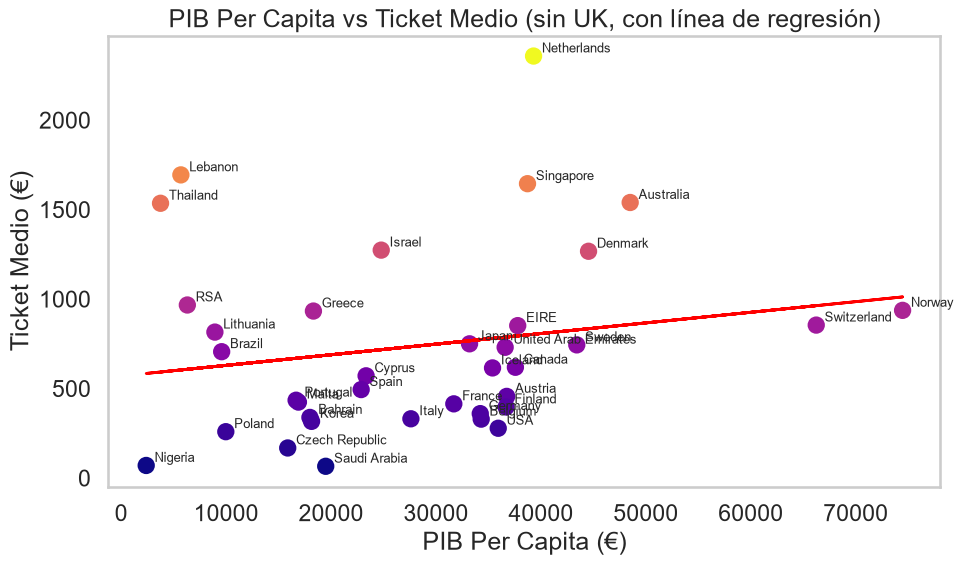

In [ ]:
# ============================================================
# 1. Ticket medio por país
# ============================================================

ticket_medio = (
    ventas_macro.groupby('Country')
    .agg(
        ventas_totales=('LineTotal', 'sum'),
        num_transacciones=('Invoice', 'nunique')   # número de facturas distintas
    )
    .reset_index()
)

ticket_medio['ticket_medio'] = ticket_medio['ventas_totales'] / ticket_medio['num_transacciones']


# ============================================================
# 2. Macroeconomía limpia (último año válido por país)
# ============================================================

macro_df = (
    ventas_macro.dropna(subset=['PIB anual (M€)'])
    .sort_values('Year')
    .groupby('Country')
    .tail(1)
)

macro_df = macro_df[['Country', 'PIB Per Capita (€)', 'PIB anual (M€)',
                     'Deuda total (M.€)', 'Deuda (%PIB)', 'Deuda Per Cápita',
                     'Tasa de desempleo', 'Población']]


# ============================================================
# 3. Unir ticket medio + macroeconomía
# ============================================================

df_pib_ticket = ticket_medio.merge(macro_df, on='Country')


# ============================================================
# 4. Correlación PIB per cápita ↔ ticket medio
# ============================================================

corr_pib_ticket = df_pib_ticket[['ticket_medio', 'PIB Per Capita (€)']].corr().iloc[0,1]
corr_pib_ticket # 0,183 debil y positiva


# ============================================================
# 5. Scatterplot PIB per cápita vs ticket medio
# ============================================================

plt.figure(figsize=(10,6))

# Scatter
plt.scatter(df_pib_ticket['PIB Per Capita (€)'], df_pib_ticket['ticket_medio'],
            c=df_pib_ticket['ticket_medio'], cmap='viridis', s=120)

# Línea de regresión
x = df_pib_ticket['PIB Per Capita (€)']
y = df_pib_ticket['ticket_medio']
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

# Etiquetas
for i, row in df_pib_ticket.iterrows():
    plt.text(row['PIB Per Capita (€)'] + 800,
             row['ticket_medio'] + 20,
             row['Country'], fontsize=9)

plt.xlabel('PIB Per Capita (€)')
plt.ylabel('Ticket Medio (€)')
plt.title('PIB Per Capita vs Ticket Medio (con línea de regresión)')
plt.grid(False)
plt.tight_layout()
plt.show()



# ============================================================
# 6. Scatterplot sin UK
# ============================================================

df_pib_ticket_sin_uk = df_pib_ticket[df_pib_ticket['Country'] != 'United Kingdom']

plt.figure(figsize=(10,6))

# Scatter
plt.scatter(df_pib_ticket_sin_uk['PIB Per Capita (€)'], df_pib_ticket_sin_uk['ticket_medio'],
            c=df_pib_ticket_sin_uk['ticket_medio'], cmap='plasma', s=120)

# Línea de regresión
x2 = df_pib_ticket_sin_uk['PIB Per Capita (€)']
y2 = df_pib_ticket_sin_uk['ticket_medio']
m2, b2 = np.polyfit(x2, y2, 1)
plt.plot(x2, m2*x2 + b2, color='red', linewidth=2)

# Etiquetas
for i, row in df_pib_ticket_sin_uk.iterrows():
    plt.text(row['PIB Per Capita (€)'] + 800,
             row['ticket_medio'] + 20,
             row['Country'], fontsize=9)

plt.xlabel('PIB Per Capita (€)')
plt.ylabel('Ticket Medio (€)')
plt.title('PIB Per Capita vs Ticket Medio (sin UK, con línea de regresión)')
plt.grid(False)
plt.tight_layout()
plt.show()

# Conclusión sobre la tendencia (opinión)
# La línea de regresión muestra una tendencia al alza débil: a medida que aumenta el PIB
# per cápita, el ticket medio también tiende a subir ligeramente. Sin embargo, la dispersión
# de los puntos es alta y la correlación es baja, lo que indica que esta relación no es fuerte.
# En general, el PIB per cápita influye algo, pero no es un factor determinante del ticket medio.





#### 2.5.3. Desempleo vs ventas

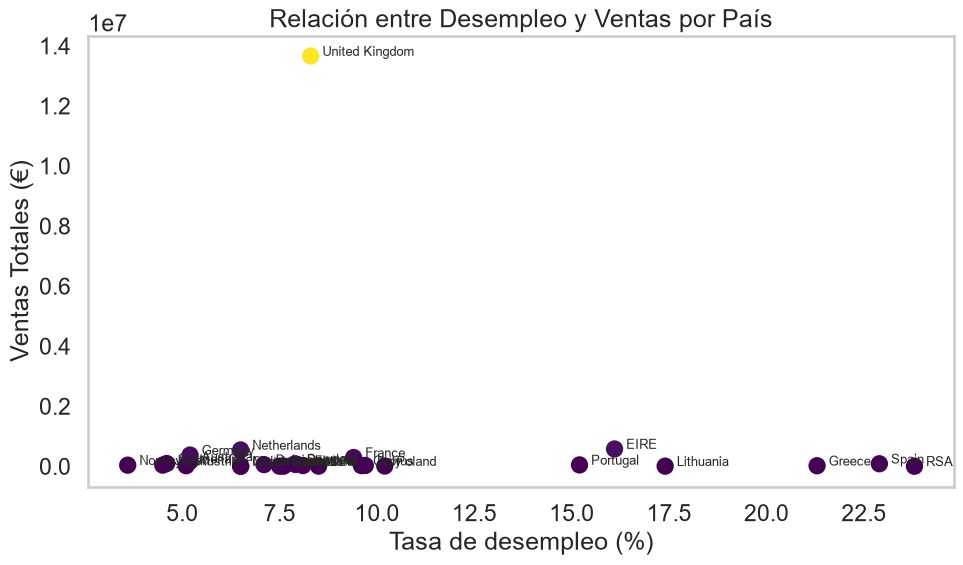

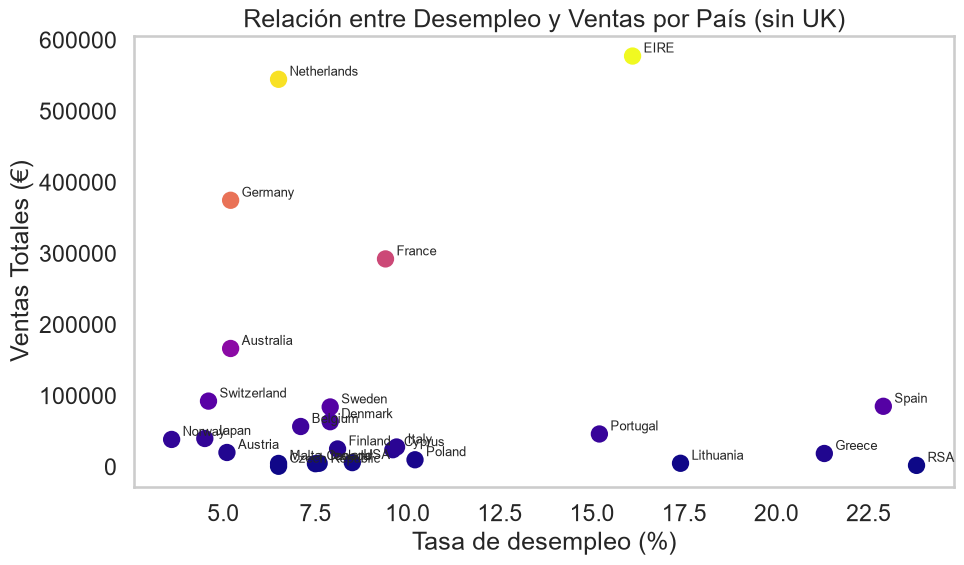

In [12]:
# ============================================================
# Desempleo por ventas (unión de datos)
# ============================================================

df_desempleo_ventas = ventas_pais_full.merge(
    macro_df[['Country', 'Tasa de desempleo']],
    on='Country'
)

corr_desempleo_ventas = df_desempleo_ventas[['LineTotal', 'Tasa de desempleo']].corr().iloc[0,1]
corr_desempleo_ventas # -0,056 negativa muy débil, no influye practicamente

# ============================================================
# Scatterplot
# ============================================================

plt.figure(figsize=(10,6))

plt.scatter(df_desempleo_ventas['Tasa de desempleo'], df_desempleo_ventas['LineTotal'],
            c=df_desempleo_ventas['LineTotal'], cmap='viridis', s=120)

for i, row in df_desempleo_ventas.iterrows():
    plt.text(row['Tasa de desempleo'] + 0.3,
             row['LineTotal'] + 5000,
             row['Country'], fontsize=9)

plt.xlabel('Tasa de desempleo (%)')
plt.ylabel('Ventas Totales (€)')
plt.title('Relación entre Desempleo y Ventas por País')
plt.grid(False)
plt.tight_layout()
plt.show()

# ============================================================
# Scatterplot sin UK
# ============================================================
df_desempleo_ventas_sin_uk = df_desempleo_ventas[df_desempleo_ventas['Country'] != 'United Kingdom']

plt.figure(figsize=(10,6))

plt.scatter(df_desempleo_ventas_sin_uk['Tasa de desempleo'], df_desempleo_ventas_sin_uk['LineTotal'],
            c=df_desempleo_ventas_sin_uk['LineTotal'], cmap='plasma', s=120)

for i, row in df_desempleo_ventas_sin_uk.iterrows():
    plt.text(row['Tasa de desempleo'] + 0.3,
             row['LineTotal'] + 5000,
             row['Country'], fontsize=9)

plt.xlabel('Tasa de desempleo (%)')
plt.ylabel('Ventas Totales (€)')
plt.title('Relación entre Desempleo y Ventas por País (sin UK)')
plt.grid(False)
plt.tight_layout()
plt.show()


#CONCLUSIONES
# -La correlación entre desempleo y ventas es prácticamente nula (-0.05). Lo que confirma que los países con más paro no compran más ni menos.
# El desempleo no parece influir en el volumen de ventas y no es un factor explicativo del mercado.

#### 2.5.4. Deuda Publica vs ventas

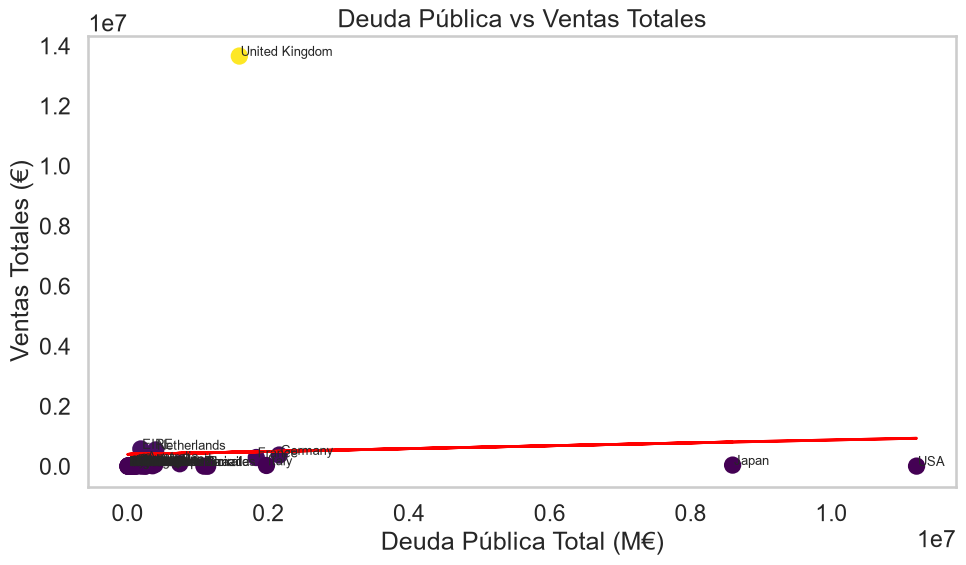

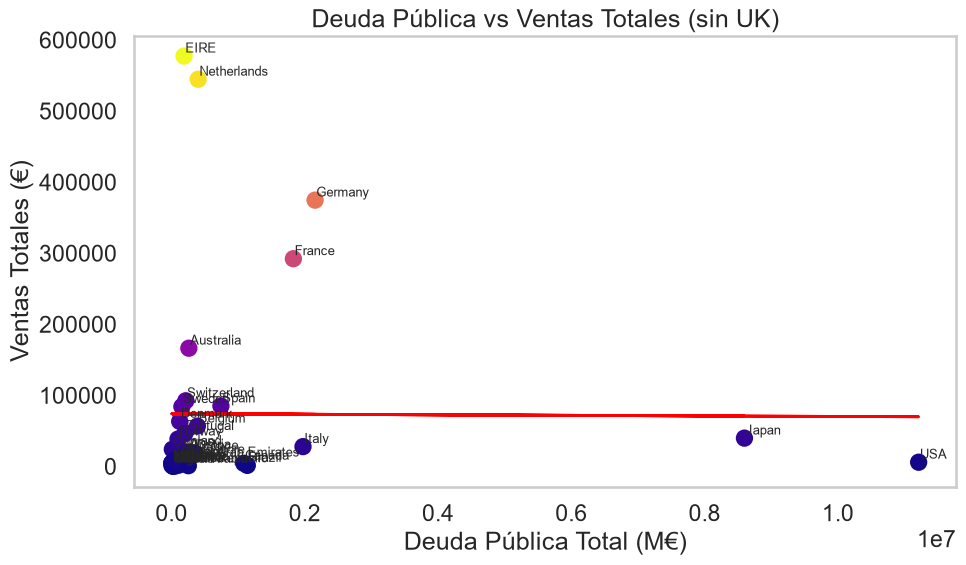

In [13]:
# ============================================================
# Deuda pública vs ventas (unión de datos)
# ============================================================

df_deuda_ventas = ventas_pais_full.merge(
    macro_df[['Country', 'Deuda total (M.€)']],
    on='Country'
)

corr_deuda_ventas = df_deuda_ventas[['LineTotal', 'Deuda total (M.€)']].corr().iloc[0,1]
corr_deuda_ventas # 0.04866084619667595 positiva demasiado débil


# ============================================================
# Versión Con UK
# ============================================================

# Limpiar NaNs para evitar errores en polyfit
df_deuda_ventas_clean = df_deuda_ventas.dropna(subset=['Deuda total (M.€)'])

# Línea de regresión (modelo idéntico al que usaste)
x2 = df_deuda_ventas_clean['Deuda total (M.€)']
y2 = df_deuda_ventas_clean['LineTotal']

m2, b2 = np.polyfit(x2, y2, 1)

plt.figure(figsize=(10,6))

# Scatter
plt.scatter(x2, y2, c=y2, cmap='viridis', s=120)

# Línea de regresión
plt.plot(x2, m2*x2 + b2, color='red', linewidth=2)

# Etiquetas
for i, row in df_deuda_ventas_clean.iterrows():
    plt.text(row['Deuda total (M.€)'] + 20000,
             row['LineTotal'] + 5000,
             row['Country'], fontsize=9)

plt.xlabel('Deuda Pública Total (M€)')
plt.ylabel('Ventas Totales (€)')
plt.title('Deuda Pública vs Ventas Totales')
plt.grid(False)
plt.tight_layout()
plt.show()

# ============================================================
# Versión sin UK
# ============================================================

df_deuda_ventas_sin_uk = df_deuda_ventas_clean[df_deuda_ventas_clean['Country'] != 'United Kingdom']

x3 = df_deuda_ventas_sin_uk['Deuda total (M.€)']
y3 = df_deuda_ventas_sin_uk['LineTotal']

m3, b3 = np.polyfit(x3, y3, 1)

plt.figure(figsize=(10,6))

plt.scatter(x3, y3, c=y3, cmap='plasma', s=120)
plt.plot(x3, m3*x3 + b3, color='red', linewidth=2)

for i, row in df_deuda_ventas_sin_uk.iterrows():
    plt.text(row['Deuda total (M.€)'] + 20000,
             row['LineTotal'] + 5000,
             row['Country'], fontsize=9)

plt.xlabel('Deuda Pública Total (M€)')
plt.ylabel('Ventas Totales (€)')
plt.title('Deuda Pública vs Ventas Totales (sin UK)')
plt.grid(False)
plt.tight_layout()
plt.show()


# CONCLUSIONES:
# La correlación entre deuda pública y ventas es prácticamente nula (0,04). Aunque la línea
# de regresión muestra una ligera pendiente positiva, la relación es tan débil que no permite
# concluir que un mayor nivel de deuda influya en el volumen de ventas. En la práctica, los
# países muy endeudados no compran más ni menos de forma apreciable. La deuda pública no es
# un factor explicativo del comportamiento de compra en este mercado.






#### 2.5.5. Poblacion vs ventas

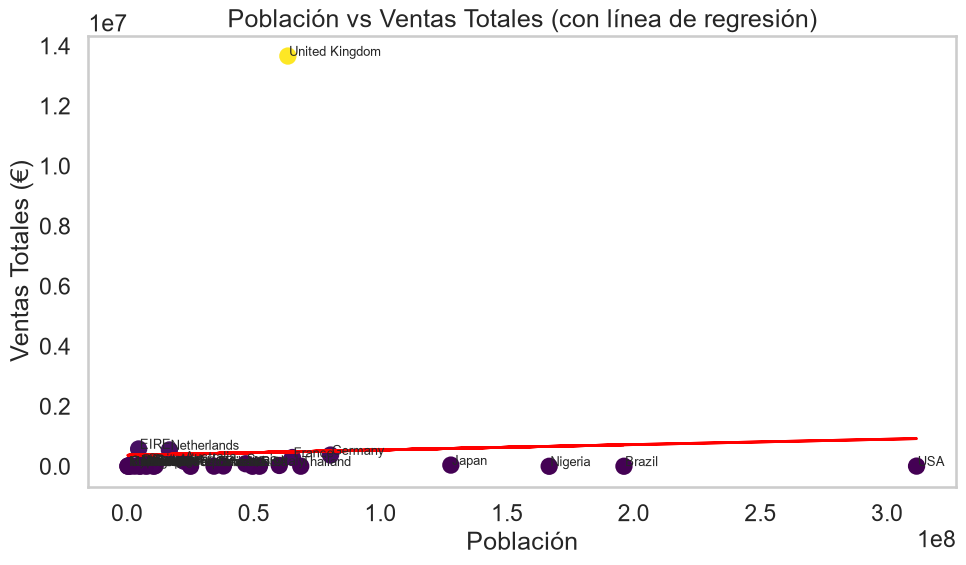

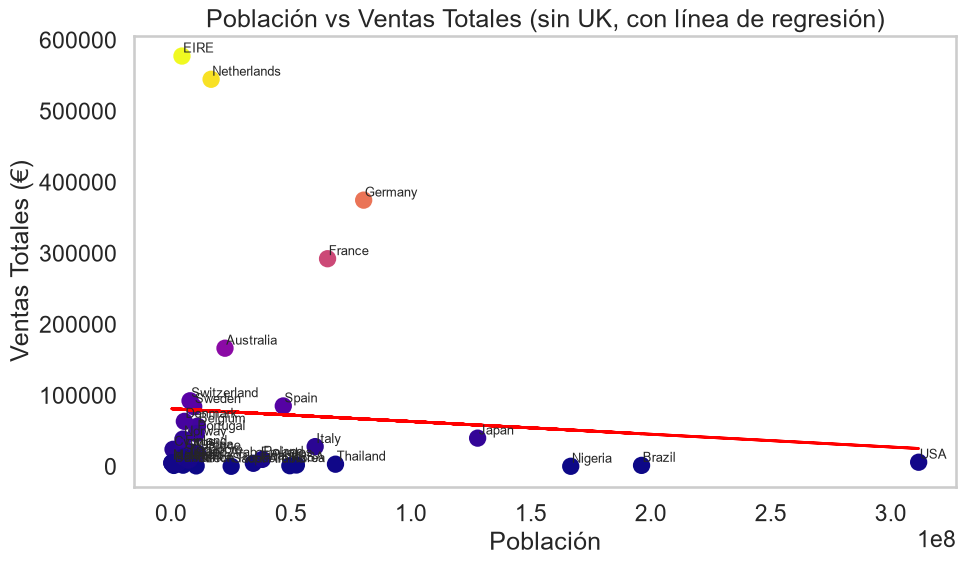

In [14]:
# ============================================================
# Población vs ventas (unión de datos)
# ============================================================

df_poblacion_ventas = ventas_pais_full.merge(
    macro_df[['Country', 'Población']],
    on='Country'
)

# Calcular correlación población vs ventas
corr_poblacion_ventas = df_poblacion_ventas[['Población', 'LineTotal']].corr().iloc[0,1]
corr_poblacion_ventas # 0,05 positiva y debil


# Limpiar NaNs
df_poblacion_ventas_clean = df_poblacion_ventas.dropna(subset=['Población'])

# ============================================================
# Versión con UK
# ============================================================

plt.figure(figsize=(10,6))

# Scatter
x = df_poblacion_ventas_clean['Población']
y = df_poblacion_ventas_clean['LineTotal']
plt.scatter(x, y, c=y, cmap='viridis', s=120)

# Línea de regresión (tu modelo)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

# Etiquetas
for i, row in df_poblacion_ventas_clean.iterrows():
    plt.text(row['Población'] + 500000,
             row['LineTotal'] + 5000,
             row['Country'], fontsize=9)

plt.xlabel('Población')
plt.ylabel('Ventas Totales (€)')
plt.title('Población vs Ventas Totales (con línea de regresión)')
plt.grid(False)
plt.tight_layout()
plt.show()


# ============================================================
# Versión sin UK
# ============================================================

df_poblacion_ventas_sin_uk = df_poblacion_ventas_clean[df_poblacion_ventas_clean['Country'] != 'United Kingdom']

# Correlación población vs ventas sin UK
corr_poblacion_ventas_sin_uk = df_poblacion_ventas_sin_uk[['Población', 'LineTotal']].corr().iloc[0,1]
corr_poblacion_ventas_sin_uk # -0,08

plt.figure(figsize=(10,6))

x2 = df_poblacion_ventas_sin_uk['Población']
y2 = df_poblacion_ventas_sin_uk['LineTotal']
plt.scatter(x2, y2, c=y2, cmap='plasma', s=120)

# Línea de regresión (tu modelo)
m2, b2 = np.polyfit(x2, y2, 1)
plt.plot(x2, m2*x2 + b2, color='red', linewidth=2)

for i, row in df_poblacion_ventas_sin_uk.iterrows():
    plt.text(row['Población'] + 500000,
             row['LineTotal'] + 5000,
             row['Country'], fontsize=9)

plt.xlabel('Población')
plt.ylabel('Ventas Totales (€)')
plt.title('Población vs Ventas Totales (sin UK, con línea de regresión)')
plt.grid(False)
plt.tight_layout()
plt.show()

# Conclusiones

# La correlación con UK incluido es ligeramente positiva (0,05), lo que sugiere una tendencia
# muy débil a que los países más poblados tengan algo más de ventas. Sin embargo, al eliminar UK,
# la correlación pasa a ser negativa (-0,08), indicando que la relación no solo es débil, sino
# inconsistente. En conjunto, la población no explica el volumen de ventas: tener más habitantes
# no implica vender más ni menos de forma apreciable.




#### 2.5.6. ventas totales por PIB Per Capita (€)


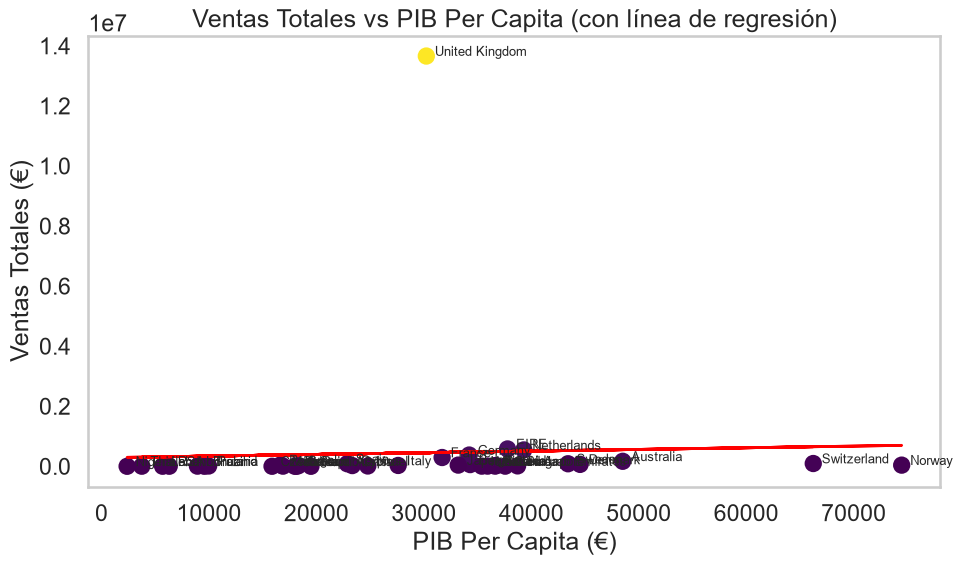

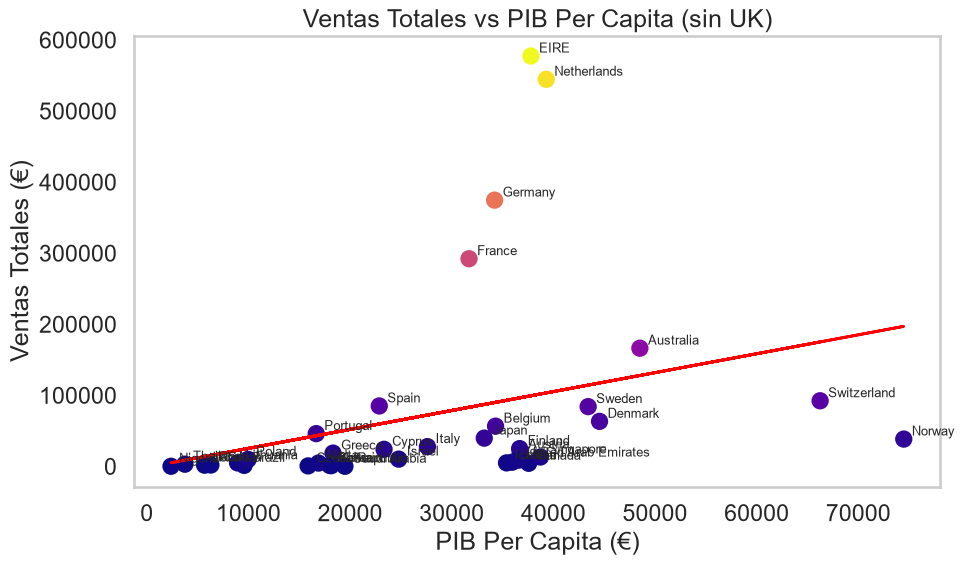

In [15]:

df_capita_ventas = ventas_pais_full.merge(
    macro_df[['Country', 'PIB Per Capita (€)']],
    on='Country'
)

# Calcular correlación pib per capita vs ventas
corr_capita_ventas = df_capita_ventas[['PIB Per Capita (€)', 'LineTotal']].corr().iloc[0,1]
corr_capita_ventas # 0,04 

df_capita_ventas_clean = df_capita_ventas.dropna(subset=['PIB Per Capita (€)'])

# ============================================================
# Versión con UK
# ============================================================

plt.figure(figsize=(10,6))

x = df_capita_ventas_clean['PIB Per Capita (€)']
y = df_capita_ventas_clean['LineTotal']

# Scatter
plt.scatter(x, y, c=y, cmap='viridis', s=120)

# Línea de regresión (idéntica a tu modelo)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

# Etiquetas
for i, row in df_capita_ventas_clean.iterrows():
    plt.text(row['PIB Per Capita (€)'] + 800,
             row['LineTotal'] + 5000,
             row['Country'], fontsize=9)

plt.xlabel('PIB Per Capita (€)')
plt.ylabel('Ventas Totales (€)')
plt.title('Ventas Totales vs PIB Per Capita (con línea de regresión)')
plt.grid(False)
plt.tight_layout()
plt.show()

# ============================================================
# Versión sin UK
# ============================================================

df_capita_ventas_sin_uk = df_capita_ventas_clean[df_capita_ventas_clean['Country'] != 'United Kingdom']


# Calcular correlación pib per capita vs ventas sin uk
corr_capita_ventas_sin_uk = df_capita_ventas_sin_uk[['PIB Per Capita (€)', 'LineTotal']].corr().iloc[0,1]
corr_capita_ventas_sin_uk # 0,30

plt.figure(figsize=(10,6))

x2 = df_capita_ventas_sin_uk['PIB Per Capita (€)']
y2 = df_capita_ventas_sin_uk['LineTotal']

plt.scatter(x2, y2, c=y2, cmap='plasma', s=120)

m2, b2 = np.polyfit(x2, y2, 1)
plt.plot(x2, m2*x2 + b2, color='red', linewidth=2)

for i, row in df_capita_ventas_sin_uk.iterrows():
    plt.text(row['PIB Per Capita (€)'] + 800,
             row['LineTotal'] + 5000,
             row['Country'], fontsize=9)

plt.xlabel('PIB Per Capita (€)')
plt.ylabel('Ventas Totales (€)')
plt.title('Ventas Totales vs PIB Per Capita (sin UK)')
plt.grid(False)
plt.tight_layout()
plt.show()

# CONCLUSIONES:
# Con UK incluido, la correlación entre PIB per cápita y ventas totales es prácticamente nula (0,04).
# Esto indica que el nivel de riqueza media de un país no explica el volumen de ventas: los países
# más ricos no compran más de forma apreciable.

# Sin UK, la correlación aumenta a 0,30, mostrando una relación positiva algo más clara. Aun así,
# sigue siendo una correlación débil: aunque los países con mayor PIB per cápita tienden a tener
# más ventas, la relación no es lo suficientemente fuerte como para considerarla determinante.

# En conjunto, el PIB per cápita no es un factor explicativo sólido del volumen de ventas. Otros
# elementos del mercado (hábitos de consumo, cultura de compra, tipo de cliente, penetración del
# producto) parecen tener mucho más peso.



# 3. Exportar ventas_macro a la carpeta 3_processed

In [16]:
ventas_macro.to_csv("../Data/3_processed/ventas.csv", sep=";", decimal=",", index=False)


# 4. 📈 Conclusiones del Análisis Exploratorio (EDA)

## 🕒 1. Estacionalidad de las ventas
- Las ventas presentan un patrón estacional muy marcado.  
- Los meses con mayor volumen de ventas son septiembre, octubre y especialmente noviembre.  
- Tras noviembre, las ventas caen en diciembre y se mantienen bajas durante los primeros meses del año.  
- El negocio muestra un pico fuerte en otoño, probablemente vinculado a compras previas a Navidad.

---

## 📦 2. Análisis de productos

### Productos equilibrados (alto volumen + alto valor)
- **white hanging heart t-light holder**  
- **paper craft, little birdie**  
Ambos aparecen en el top de cantidad y en el top de ingresos → buena rotación y buen rendimiento económico.

### Producto muy vendido pero barato
- **world war 2 gliders asstd designs**  
Es el nº1 en cantidad vendida, pero no aparece en ingresos → producto de bajo precio y bajo impacto económico.

### Producto poco vendido pero caro
- **regency cakestand 3 tier**  
No está en el top de cantidad, pero es el nº1 en dinero generado → producto premium.

---

## ❌ 3. Cancelaciones
- El porcentaje total de cancelaciones es muy bajo (~2.2%).  
- El porcentaje mensual es estable entre 1.5% y 3%.  
- Los meses con menos ventas (enero, diciembre, mayo) presentan más cancelaciones, posiblemente por devoluciones post-navidad.  
- Los meses de mayor actividad (septiembre–noviembre) tienen menos cancelaciones → mejor rendimiento operativo en picos de demanda.

---

## 🌍 4. Análisis por países (incluyendo UK)
- **United Kingdom** domina en volumen y valor → fuerte dependencia geográfica.  
- **France** actúa como mercado premium: genera mucho dinero con menos unidades.  
- **Netherlands, EIRE y Germany** son mercados secundarios pero estables.  
- Se identifican mercados de volumen, premium y equilibrados.

---

## 🌍 5. Análisis por países (sin UK)
- **EIRE y Netherlands** son los mercados más fuertes sin UK.  
- **France** sigue siendo mercado premium.  
- **Germany y Denmark** son mercados equilibrados.  
- **Australia, Sweden, Switzerland, Belgium y Spain** muestran bajo volumen y valor → mercados marginales.  
- Sin UK, los países que sostienen el negocio son EIRE, Netherlands, France y Germany.

---

## 👥 6. Mejores clientes
- 6 de los 10 mejores clientes son de **United Kingdom**, confirmando la dependencia geográfica.  
- Netherlands aporta un cliente muy potente (521k).  
- EIRE aporta dos clientes fuertes (300k y 265k).  
- Se identifican clientes estratégicos para acciones de fidelización (VIP, descuentos, programas exclusivos).

---

## 📊 7. Análisis macroeconómico
- Los datos macroeconómicos estaban repetidos por factura → se corrige agregando por país y usando el último año disponible.  
- *ventas_pais* solo contenía el TOP 5 → se crea *ventas_pais_full* para incluir todos los países.  
- Correlación PIB ↔ ventas:
  - Con UK: correlación débil (~0.298).  
  - Sin UK: correlación fuertemente negativa (~ -0.875).  
- El negocio no depende del tamaño económico del país, sino de factores culturales, nichos o clientes estratégicos.  
- UK actuaba como outlier y ocultaba la relación real.

---

## 💶 8. PIB per cápita ↔ ticket medio
- La regresión muestra una tendencia al alza débil: mayor PIB per cápita → ticket medio ligeramente mayor.  
- La dispersión es alta → relación poco determinante.

---

## 📉 9. Desempleo ↔ ventas
- Correlación prácticamente nula (-0.05).  
- El desempleo no influye en el volumen de ventas.

---

## 💰 10. Deuda pública ↔ ventas
- Correlación nula (0.04).  
- La deuda pública no explica el comportamiento de compra.

---

## 👥 11. Población ↔ ventas
- Con UK: correlación ligeramente positiva (0.05).  
- Sin UK: correlación negativa (-0.08).  
- La población no explica el volumen de ventas.

---

## 💵 12. PIB per cápita ↔ ventas totales
- Con UK: correlación nula (0.04).  
- Sin UK: correlación débil positiva (0.30).  
- El PIB per cápita no es un factor explicativo sólido del volumen de ventas.  
- Otros factores (hábitos de consumo, cultura de compra, tipo de cliente, penetración del producto) tienen más peso.
